# 04. Linear Regression

## 📚 Learning Objectives

By completing this notebook, you will:
- Fit and interpret linear regression models
- Use train/test split and basic metrics
- Plot fits and residuals

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 1, lesson 04 "Linear Regression" and Course 01 (AIAT 111) — Unit 3, lesson 04: the fit is still a loss minimised by gradient descent; here the focus is residual diagnostics.

**Used later in:** Course 05 — Unit 4, lesson 07, which formalises how such a fit should be scored.

---


## 🎯 The case: Zillow bought houses on its own price predictions

Zillow's *Zestimate* is a house-price model, and in 2018 the company decided to trade on
it. **Zillow Offers** made algorithmic cash offers on homes, bought them, and resold them.
The prediction was no longer advice on a web page; it was the purchase price.

The decision came on **2 November 2021**. CEO Rich Barton announced Zillow would wind down the
home-buying business and cut Zillow's workforce by **approximately 25%**, because "the
unpredictability in forecasting home prices far exceeds what we anticipated". The Homes
segment had lost **$422 million before tax in the third quarter of 2021** alone, including
a **$304 million write-down** on homes bought for more than Zillow now expected to sell
them for (Zillow Group, *Third-Quarter 2021 Financial Results*, 2 November 2021). Across
2021 those write-downs reached **$407.9 million** on the 15,436 homes the programme sold
(Zillow Group 2021 Form 10-K).

The model was not stupid. It was a good estimator of an average, deployed where average
error was not the thing that mattered — because Zillow only bought the houses where its
estimate was *high relative to the seller's price*, which is precisely a selection of the
cases where the model was most likely to be wrong in one direction.

**What goes wrong without residual diagnostics.** You are about to fit house values in
California and get **test R² = 0.4589** from income alone, and **0.5758** from all eight
features. Half the variance, unexplained. And the scatter will show a **vertical stripe at
5.0** — the $500,001 census cap from Unit 2 lesson 06 — where the model happily predicts
above and below a ceiling it cannot know exists. An R² printed on its own would hide both
facts.


## The Story

**BEFORE**: You know data cleaning and visualization, but don't know how to build predictive models.

**AFTER**: You'll master linear regression - the foundation of machine learning - to predict continuous values from data!

**Why this matters**: Linear Regression is essential for understanding how ML models learn from data and make predictions!

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** the California Housing dataset — 20,640 census block groups from
  the 1990 U.S. census (shipped with scikit-learn, no download needed). Features:
  median income, house age, rooms per household, occupancy, latitude/longitude.
  Target: median house value per block group, in $100,000s.
- **Real data:** `titanic.csv` — used at the end to show what happens when you
  push linear regression into a classification job.
- sklearn (LinearRegression, train_test_split, R²/MSE/MAE)

**Outputs:** What you'll see when you run the cells

- A fitted line, a coefficient table, and predicted-vs-actual plots
- Honest R² values (around 0.46 for one feature, 0.58 for eight) — real data is noisy

---


In [1]:
# WHAT: Import the data, plotting, and sklearn regression tools.
# WHY: train_test_split and the metrics module are as essential as the model itself - evaluation is part of modeling.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("✓ Imports ready")

✓ Imports ready


In [2]:
# WHAT: Set the plot style and print the notebook banner.
# WHY: A consistent style keeps every figure in the course readable and comparable.

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("=" * 70)
print("04. Linear Regression")
print("=" * 70)

04. Linear Regression


1. SIMPLE LINEAR REGRESSION



1. Simple Linear Regression
----------------------------------------------------------------------
Real dataset: 20,640 California census block groups

First rows of the real data (median_income in $10,000s, value in $100,000s):
   median_income  median_house_value
0         8.3252               4.526
1         8.3014               3.585
2         7.2574               3.521
3         5.6431               3.413
4         3.8462               3.422

Summary:
       median_income  median_house_value
count      20640.000           20640.000
mean           3.871               2.069
std            1.900               1.154
min            0.500               0.150
25%            2.563               1.196
50%            3.535               1.797
75%            4.743               2.647
max           15.000               5.000

Model Parameters:
Intercept: 0.4446
Coefficient: 0.4193
  -> every extra $10,000 of median income is worth about $41,934 of median house value

Training R²: 0.4770
Test

/Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


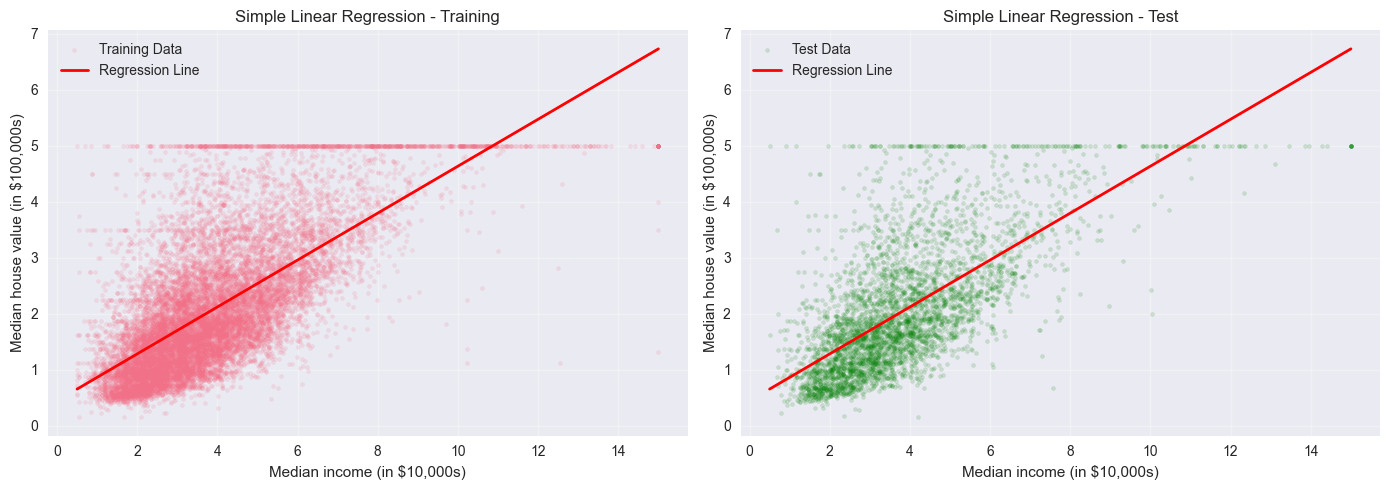


✓ Plot drawn and saved
   Look at the flat band of points along the very top of BOTH panels:
   992 of 20,640 block groups (4.8%) sit at 5.0 because
   the census release CAPPED median house value at $500,001. Real data carries
   real artefacts, and the red line runs straight through that ceiling.


In [3]:
# WHAT: Fit a simple (one-feature) linear regression: median income -> median house value.
# WHY: One feature keeps the math visible - the fitted line IS the model, and test R-squared
#      tells us how well it generalises to blocks it never saw.

print("\n1. Simple Linear Regression")
print("-" * 70)

from sklearn.datasets import fetch_california_housing

# Real data: 20,640 California census block groups, 1990 census.
housing = fetch_california_housing(as_frame=True)
df_simple = housing.frame[['MedInc', 'MedHouseVal']].rename(
    columns={'MedInc': 'median_income', 'MedHouseVal': 'median_house_value'})

print(f"Real dataset: {len(df_simple):,} California census block groups")
print("\nFirst rows of the real data (median_income in $10,000s, value in $100,000s):")
print(df_simple.head())
print("\nSummary:")
print(df_simple.describe().round(3).to_string())

X = df_simple[['median_income']]
y = df_simple['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)
y_train_pred = model_simple.predict(X_train)
y_test_pred = model_simple.predict(X_test)

print("\nModel Parameters:")
print(f"Intercept: {model_simple.intercept_:.4f}")
print(f"Coefficient: {model_simple.coef_[0]:.4f}")
print(f"  -> every extra $10,000 of median income is worth about "
      f"${model_simple.coef_[0] * 100000:,.0f} of median house value")

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
print(f"\nTraining R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MAE: {test_mae:.4f} (= ${test_mae * 100000:,.0f})")
print("\n💡 R² near 0.46 means income alone explains under half the variation in")
print("   house value. That is what one real feature buys you - not a defect.")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_train, y_train, alpha=0.15, s=8, label='Training Data')
line_x = np.linspace(X['median_income'].min(), X['median_income'].max(), 100).reshape(-1, 1)
axes[0].plot(line_x, model_simple.predict(line_x), 'r-', linewidth=2, label='Regression Line')
axes[0].set_xlabel('Median income (in $10,000s)')
axes[0].set_ylabel('Median house value (in $100,000s)')
axes[0].set_title('Simple Linear Regression - Training')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].scatter(X_test, y_test, alpha=0.15, s=8, color='green', label='Test Data')
axes[1].plot(line_x, model_simple.predict(line_x), 'r-', linewidth=2, label='Regression Line')
axes[1].set_xlabel('Median income (in $10,000s)')
axes[1].set_ylabel('Median house value (in $100,000s)')
axes[1].set_title('Simple Linear Regression - Test')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('10_linear_regression.png', dpi=300, bbox_inches='tight')
plt.show()          # show it in the notebook too - a figure nobody sees teaches nothing
n_capped = int((y >= 5.0).sum())
print(f"\n✓ Plot drawn and saved")
print(f"   Look at the flat band of points along the very top of BOTH panels:")
print(f"   {n_capped} of {len(y):,} block groups ({n_capped/len(y):.1%}) sit at 5.0 because")
print(f"   the census release CAPPED median house value at $500,001. Real data carries")
print(f"   real artefacts, and the red line runs straight through that ceiling.")

**Read the figure.** Two panels, training on the left and test on the right, each with
median income on the x-axis and median house value on the y-axis, and the same red fitted
line drawn on both. Two things to see. First, the line rises: every extra $10,000 of median
income is worth about $41,900 of house value, and the two panels look alike — the model
generalises. Second, and more important, there is a **hard flat band of points along the top
of both panels at y = 5.0**. Those are block groups whose median value was censored at
$500,001 before the data was published. The red line passes straight through that ceiling and
keeps climbing, because a straight line has no way to represent a cap. The scatter is also
wide at every income level: income alone explains under half the variation (test R² 0.459).

2. MULTIPLE LINEAR REGRESSION




2. Multiple Linear Regression
----------------------------------------------------------------------
Coefficients (target is in $100,000s):
  MedInc      : +0.4487
  HouseAge    : +0.0097
  AveRooms    : -0.1233
  AveBedrms   : +0.7831
  Population  : -0.0000
  AveOccup    : -0.0035
  Latitude    : -0.4198
  Longitude   : -0.4337

Test R² Score: 0.5758   (one feature alone gave 0.4589)
Test RMSE: 0.7456 (= $74,558)

💡 Latitude and Longitude both carry large NEGATIVE coefficients. The model is
   not saying 'north is cheap'; it is using coordinates to locate the expensive
   coastal strip. Coefficients describe the fit, not causation.


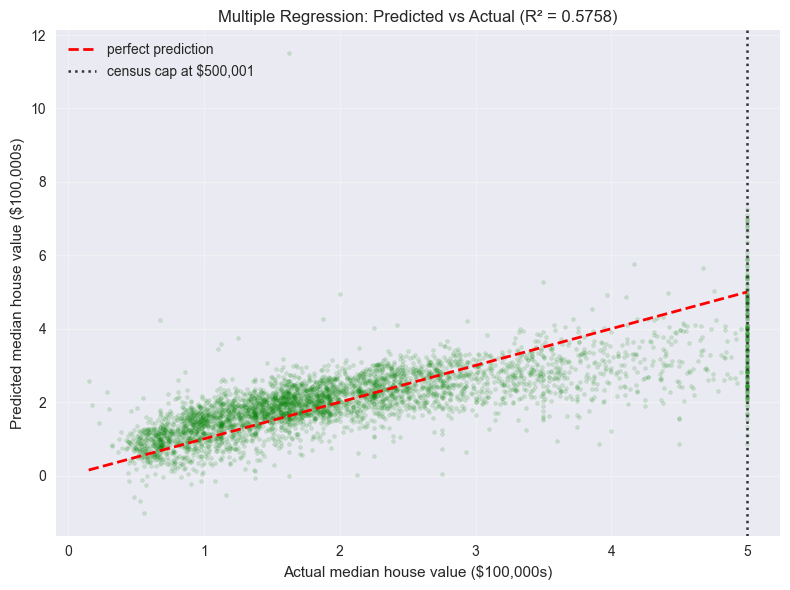

✓ Multiple regression plot drawn and saved
   The vertical stripe of points at x = 5.0 is the $500,001 cap again:
   184 capped blocks in this test set. The model predicts ABOVE 5.0 for
   34 of them and BELOW for 150 - a straight line cannot know
   about a ceiling, so it scatters its guesses on both sides of one true value.
   Look at the bottom-left too: 15 blocks get a NEGATIVE predicted price,
   and the highest prediction is 11.5 (= $1,150,033),
   6.5 above any value the data can contain.

Summary
Simple (median income only):  test R² = 0.4589
Multiple (all 8 features):    test R² = 0.5758

Next Steps: Continue to Example 05 (supervised learning concepts),
then Example 06 for classification in practice


In [4]:
# WHAT: Fit a multiple linear regression on all eight housing features.
# WHY: Real prediction uses many features; each coefficient says how much that feature moves
#      the price with the others held fixed - and some of them are surprising.

print("\n\n2. Multiple Linear Regression")
print("-" * 70)

FEATURES = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
            'Population', 'AveOccup', 'Latitude', 'Longitude']
df_multiple = housing.frame
X_multiple = df_multiple[FEATURES]
y_multiple = df_multiple['MedHouseVal']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple, y_multiple, test_size=0.2, random_state=42)
model_multiple = LinearRegression()
model_multiple.fit(X_train_m, y_train_m)
y_train_pred_m = model_multiple.predict(X_train_m)
y_test_pred_m = model_multiple.predict(X_test_m)

print("Coefficients (target is in $100,000s):")
for feature, coef in zip(FEATURES, model_multiple.coef_):
    print(f"  {feature:12s}: {coef:+.4f}")

test_r2_m = r2_score(y_test_m, y_test_pred_m)
test_rmse_m = mean_squared_error(y_test_m, y_test_pred_m) ** 0.5
print(f"\nTest R² Score: {test_r2_m:.4f}   (one feature alone gave {test_r2:.4f})")
print(f"Test RMSE: {test_rmse_m:.4f} (= ${test_rmse_m * 100000:,.0f})")
print("\n💡 Latitude and Longitude both carry large NEGATIVE coefficients. The model is")
print("   not saying 'north is cheap'; it is using coordinates to locate the expensive")
print("   coastal strip. Coefficients describe the fit, not causation.")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test_m, y_test_pred_m, alpha=0.15, s=8, color='green')
ax.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()],
        'r--', linewidth=2, label='perfect prediction')
# Mark the census ceiling: every truly-capped block sits on this one vertical line.
ax.axvline(5.0, color='#333333', linestyle=':', linewidth=1.8,
           label='census cap at $500,001')
ax.set_xlabel('Actual median house value ($100,000s)')
ax.set_ylabel('Predicted median house value ($100,000s)')
ax.set_title(f'Multiple Regression: Predicted vs Actual (R² = {test_r2_m:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('10_multiple_regression.png', dpi=300, bbox_inches='tight')
plt.show()          # show it in the notebook too
n_cap_test = int((y_test_m >= 5.0).sum())
above_cap = int((y_test_pred_m[y_test_m >= 5.0] > 5.0).sum())
below_cap = n_cap_test - above_cap
print("✓ Multiple regression plot drawn and saved")
print(f"   The vertical stripe of points at x = 5.0 is the $500,001 cap again:")
print(f"   {n_cap_test} capped blocks in this test set. The model predicts ABOVE 5.0 for")
print(f"   {above_cap} of them and BELOW for {below_cap} - a straight line cannot know")
print(f"   about a ceiling, so it scatters its guesses on both sides of one true value.")
n_neg = int((y_test_pred_m < 0).sum())
print(f"   Look at the bottom-left too: {n_neg} blocks get a NEGATIVE predicted price,")
print(f"   and the highest prediction is {y_test_pred_m.max():.1f} (= ${y_test_pred_m.max()*100000:,.0f}),")
print(f"   {y_test_pred_m.max() - 5.0:.1f} above any value the data can contain.")

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"Simple (median income only):  test R² = {test_r2:.4f}")
print(f"Multiple (all 8 features):    test R² = {test_r2_m:.4f}")
print("\nNext Steps: Continue to Example 05 (supervised learning concepts),")
print("then Example 06 for classification in practice")

**Read the figure.** Predicted value against actual value for the held-out blocks, with
the red dashed 45-degree line marking perfect prediction. A good model puts points on that
line; the cloud here is wide, which is what R² 0.576 looks like. Two failures are visible.
The **dotted vertical line at 5.0** is the census cap, and the dense stripe of points sitting
on it is every censored block: they all share one true value while the model spreads its
predictions above and below it. The y-axis is worth reading on its own: it runs from
**below zero** — the model predicts negative house prices for a handful of the cheapest
blocks — up to **about 11.5**, more than twice the highest value the data can contain. A
least-squares line will happily do both, because nothing in it knows that prices cannot go
negative and that this target stops at 5.0. The exact counts are printed under the figure.

## 💬 Discuss

Measured: income alone gives **test R² 0.4589, MAE 0.6299 ($62,991)**; all eight features
give **R² 0.5758, RMSE 0.7456 ($74,558)**. `Latitude` **−0.4198** and `Longitude`
**−0.4337** are among the largest coefficients.

1. The notebook warns the model is "not saying north is cheap" — it is using coordinates to
   locate the expensive coastal strip. Write the sentence you would put in a report so a
   non-technical reader cannot misread those two coefficients. Then say what you would do
   if a policymaker asked you to act on them.
2. An average error of about **$63,000** per block group. Is that model good enough to (a)
   set a property tax band, (b) advise a family on an asking price, (c) let a company buy
   the house? Answer all three, and name the number *other than R²* you would want before
   answering (c).
3. Adding seven features moved R² from 0.4589 to 0.5758 — but RMSE went **up** from the
   simple model's MAE. Explain why those two facts are not contradictory, and say which
   metric you would report to a client and why.


## 🚫 When Linear Regression Hits a Dead End

**BEFORE**: We've learned linear regression for predicting continuous values.

**AFTER**: We discover we need to predict categories/classes, not continuous values!

**Why this matters**: Linear regression works for continuous predictions, but many problems require categorical predictions!

---

### The Problem We've Discovered

We've learned:
- ✅ How to use linear regression for continuous value prediction
- ✅ How to build simple and multiple linear regression models
- ✅ How to evaluate regression models

**But we have a problem:**
- ❓ **What if we need to predict categories (e.g., spam/not spam, yes/no)?**
- ❓ **What if the target variable is discrete, not continuous?**

**The Dead End (and an honest warning):**
- You *can* bolt a threshold onto linear regression, and on an easy, well-separated dataset it will even look accurate
- But the outputs are not probabilities (they fall outside [0, 1]), and the fitted line chases extreme feature values instead of the class boundary
- The next cell demonstrates both failures with measured numbers — not just claims

---

### Demonstrating the Problem

Let's fit linear regression to a classification problem twice: first on clean, easy data (where it *looks* fine), then after adding a handful of extreme-but-valid points (where it falls apart):


In [5]:
# WHAT: Use linear regression for CLASSIFICATION on the Titanic manifest, first on moderate
#       fares, then on the whole manifest including the real £512 tickets.
# WHY: The raw outputs leave [0,1] and the genuine fare outliers flatten the fitted line -
#      this failure is exactly why logistic regression exists (next example).

print("\n" + "=" * 70)
print("🚫 DEMONSTRATING THE DEAD END: Linear Regression for Classification")
print("=" * 70)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score

DATA_DIR = '../../../Course 04/datasets/raw/'
titanic = pd.read_csv(DATA_DIR + 'titanic.csv')
fare_all = titanic[['Fare', 'Survived']].dropna()

# --- Round 1: moderate fares only (linear regression *looks* fine here) ---
moderate = fare_all[fare_all['Fare'] <= 100]
X_mod = moderate[['Fare']].values
y_mod = moderate['Survived'].values

lr_mod = LinearRegression().fit(X_mod, y_mod)
raw_mod = lr_mod.predict(X_mod)
acc_mod = accuracy_score(y_mod, (raw_mod > 0.5).astype(int))
n_outside_mod = ((raw_mod < 0) | (raw_mod > 1)).sum()

print(f"\n📊 Round 1 - passengers who paid £100 or less ({len(moderate)} of {len(fare_all)}):")
print(f"   Question asked: does the ticket fare predict survival?")
print(f"   Thresholded linear regression accuracy: {acc_mod:.2%}")
print(f"   Fitted slope: {lr_mod.coef_[0]:.5f} per £1 of fare")
print(f"   Raw predictions range: {raw_mod.min():.2f} to {raw_mod.max():.2f}")
print(f"   Predictions outside [0, 1]: {n_outside_mod} of {len(moderate)}")

# --- Round 2: the FULL manifest, including the real £512 first-class tickets ---
X_all = fare_all[['Fare']].values
y_all = fare_all['Survived'].values

lr_all = LinearRegression().fit(X_all, y_all)
raw_all = lr_all.predict(X_all)
acc_all = accuracy_score(y_all, (raw_all > 0.5).astype(int))
n_outside_all = ((raw_all < 0) | (raw_all > 1)).sum()

# How do the SAME moderate-fare passengers fare under the model fitted with the outliers?
err_before = ((lr_mod.predict(X_mod) > 0.5).astype(int) != y_mod).sum()
err_after = ((lr_all.predict(X_mod) > 0.5).astype(int) != y_mod).sum()

logistic = LogisticRegression(max_iter=1000).fit(X_all, y_all)
acc_logit = accuracy_score(y_all, logistic.predict(X_all))

top_fare = fare_all['Fare'].max()
n_top = (fare_all['Fare'] == top_fare).sum()

print(f"\n📊 Round 2 - the whole manifest ({len(fare_all)} passengers), including the")
print(f"   {n_top} genuine £{top_fare:.2f} tickets (Cardeza, Lesurer and Ward - real people):")
print(f"   Thresholded linear regression accuracy: {acc_all:.2%}  (was {acc_mod:.2%})")
print(f"   Fitted slope: {lr_all.coef_[0]:.5f} per £1  (was {lr_mod.coef_[0]:.5f})")
print(f"   Raw predictions range: {raw_all.min():.2f} to {raw_all.max():.2f}")
print(f"   Predictions outside [0, 1]: {n_outside_all}")
print(f"   Errors on the SAME {len(moderate)} moderate-fare passengers: "
      f"{err_before} → {err_after}")
print(f"   Logistic regression on the same full data: {acc_logit:.2%}")

print(f"\n💡 What the numbers show:")
print(f"   - The £512 tickets are REAL, correctly labelled data - not noise to delete.")
print(f"     Least squares still lets them flatten the line: the slope fell "
      f"{1 - lr_all.coef_[0] / lr_mod.coef_[0]:.0%}.")
print(f"   - Predicting a survival 'probability' of {raw_all.max():.2f} is meaningless.")
print(f"     A probability cannot exceed 1; linear regression does not know that.")
print(f"   - Errors on the untouched moderate-fare passengers went UP ({err_before} → {err_after})")
print(f"     purely because of who else was in the training set.")
print(f"   - Linear regression also has no principled threshold: 0.5 is a guess.")

print(f"\n📋 Real-World Classification Problems:")
print(f"   1. Email: Spam (1) or Not Spam (0)")
print(f"   2. Medical: Disease (1) or Healthy (0)")
print(f"   3. Customer: Will Buy (1) or Won't Buy (0)")
print(f"   - All require predicting categories, and all need calibrated probabilities!")

print("\n" + "=" * 70)


🚫 DEMONSTRATING THE DEAD END: Linear Regression for Classification

📊 Round 1 - passengers who paid £100 or less (838 of 891):
   Question asked: does the ticket fare predict survival?
   Thresholded linear regression accuracy: 66.95%
   Fitted slope: 0.00637 per £1 of fare
   Raw predictions range: 0.22 to 0.81
   Predictions outside [0, 1]: 0 of 838

📊 Round 2 - the whole manifest (891 passengers), including the
   3 genuine £512.33 tickets (Cardeza, Lesurer and Ward - real people):
   Thresholded linear regression accuracy: 66.44%  (was 66.95%)
   Fitted slope: 0.00252 per £1  (was 0.00637)
   Raw predictions range: 0.30 to 1.59
   Predictions outside [0, 1]: 3
   Errors on the SAME 838 moderate-fare passengers: 277 → 285
   Logistic regression on the same full data: 66.55%

💡 What the numbers show:
   - The £512 tickets are REAL, correctly labelled data - not noise to delete.
     Least squares still lets them flatten the line: the slope fell 60%.
   - Predicting a survival 'proba

### What We Need Next

**The Solution**: We need classification algorithms:
- **Logistic Regression**: For binary and multi-class classification — models probabilities directly, so extreme points can't drag the boundary the way they dragged the least-squares line above
- **Decision Trees**: For non-linear classification boundaries
- **Classification metrics**: Accuracy, precision, recall, F1-score

**This dead end leads us onward:**
- Example 05 covers the supervised-learning / logistic-regression workflow
- Example 06 puts classification algorithms to work in practice
- Together they solve the classification problem that linear regression can't handle!


## ⚠️ Where this breaks

- **A straight line cannot know about a ceiling.** The target is censored at $500,001 for
  **965 of 20,640 block groups**, and **992 (4.8%)** sit at or above 5.0 — visible in the plots as a vertical stripe at 5.0.
  The model predicts above and below it, so it is guaranteed wrong on the most expensive
  4.8% of California and no metric here will tell you. Censored targets need censored-
  regression methods (Tobit, survival-style models), not OLS.
- **R² is not a measure of correctness.** It is the share of variance explained *on this
  data*, it never decreases when you add features (even random ones), and it says nothing
  about whether the linear form is right. Always look at residuals against fitted values;
  a pattern there means the model is missing structure.
- **Coefficients are not effects.** They are partial associations conditional on the other
  seven columns, and with correlated features (income, rooms, location all move together)
  they trade magnitude between each other freely. Change the feature set, change every
  coefficient.
- **Least squares gives extreme points enormous leverage — and the notebook measures it.**
  Three genuine £512 Titanic tickets cut the fitted slope by **60%** (0.00637 → 0.00252)
  and made errors *worse on the untouched moderate-fare passengers* (277 → 285). Those
  points are real, correct data. Robust regression (Huber, quantile) or a transformed
  target is the fix; deleting real rows is not.
- **The assumption that must hold: an additive linear relationship with roughly constant
  error variance.** House prices violate the second badly — errors are much larger in
  expensive areas. That is heteroscedasticity, and it means your prediction intervals are
  wrong even when your point predictions are reasonable.
- **Never use linear regression for classification, and the notebook shows why in numbers.**
  Round 2 produced "probabilities" ranging up to **1.59**. A probability cannot exceed 1.
  Lesson 05's logistic regression is the correct tool.
- **Cheaper alternative:** for pure predictive accuracy on tabular data, a gradient-boosted
  tree will usually beat OLS without any of these assumptions. Choose linear regression
  when you need coefficients somebody can read, argue with, and audit — which is a real and
  common requirement, and the reason it is still taught first.


## 📚 References

1. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2nd ed., Ch. 3 (Linear Regression). Springer. <https://www.statlearning.com>
2. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Ch. 3 (Linear Models for Regression). Springer.
3. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830. <https://arxiv.org/abs/1201.0490>
4. Erickson, N., Purucker, L., Tschalzev, A., et al. (2025). *TabArena: A Living Benchmark for Machine Learning on Tabular Data*. arXiv:2506.16791. <https://arxiv.org/abs/2506.16791>
5. Grinsztajn, L., Flöge, K., Key, O., et al. (2025). *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models*. arXiv:2511.08667. <https://arxiv.org/abs/2511.08667>
